## Assignment 2 - Mobility Modelling (LTAT.06.016)

This is the third assignment in the course Mobility Modelling. It is based on **Tutorials 5-6** and it's main aim is to learn to utilize the classical four-step transportation model. It's based very strongly on the tutorials and you can get all you need from there. Try not to only copy-paste all the solutions, but also understand what's going on behind it.

* All the tasks that require some action are highlighted in **<span style="color:#394d9e">dark blue</span>**.
* Please do not edit the code provided (that includes variable names) unless you have a good reason for it, in which case indicate clearly what you have changed.
* Feel free to create as many new cells as you need for each task.

### Library imports

In [1]:
import pandas as pd
import geopandas as gpd
import pyproj
import contextily as ctx

import math
from ipfn import ipfn
import matplotlib.pyplot as plt
from matplotlib import patheffects
import networkx as nx

In [2]:
crs_gps = pyproj.CRS.from_epsg('4326') # WGS84 Mercator (degrees)
crs_web = pyproj.CRS.from_epsg('3857') # Pseudo-Mercator (meters)
crs_est = pyproj.CRS.from_epsg('3301') # Estonian Coordinate System

### Exercise 1 - Trip generation (importing the data) (2p)

A travel demand model is a set of mathematical procedures and equations that represent the variety of transportation choices people make, and how those choices result in trips on the transportation network. This is important when planning changes in the road network, for example in order to estimate the travel demand on a new bridge or road segment. One of the most common models for estimating travel demand is the four-step model, that was introduced already in 1950s and is named for its four major steps: **trip generation, trip distribution, mode choice,** and **traffic assignment**.

For this assigment, you will need to create a four-step transportation model for Tartu. We will use a dataset that describes the distribution of workers in Tartu by district. In reality, we would of course like to have a more granular dataset, but usually such data is not publicly available in small scale. The data is in the file *data/tartu_districts.geojson* and we can use it for estimating the production and attraction of the districts using two features:
* **workers_working** - the number of people who go to work in each district
* **workers_living** - the number of working people who live in each district

**<span style="color:#394d9e">In this exercise you need to <u>import</u> the provided dataset, <u>set the feature *name* as index</u>, and <u>make two plots</u> of the dataset - one colored based on *workers_working* and the other on *workers_living*.</span>**

In [3]:
### READ THE DATA ###

tartu_districts =  gpd.read_file('data/tartu_districts.geojson')
#tartu_districts

In [4]:
### SET THE INDEX ###

tartu_districts = tartu_districts.set_index('name')
#tartu_districts

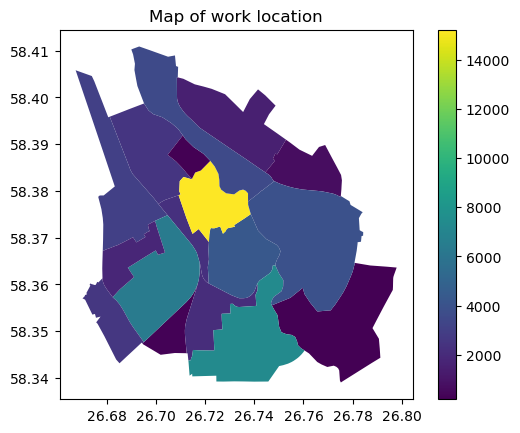

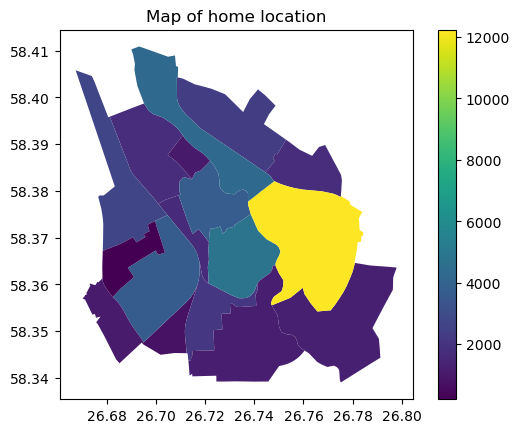

In [5]:
### PLOT THE DATA ###

# Plot based on workers_working
tartu_districts.plot(column='workers_working', legend=True)
plt.title('Map of work location')
plt.show()

# Plot based on workers_working
tartu_districts.plot(column='workers_living', legend=True)
plt.title('Map of home location')
plt.show()

Using this data, we will try to estimate the movement of people in Tartu city during the morning rush-hour. That means, that we want to observe people moving from home to work, thus **workers_living** will be the production and **workers_working** will be the attraction of each district.

<hr>

### Exercise 2 - Trip distribution (5p)

The next step is converting our production and attraction to a more specific origin-destination matrix (ODM). We will use physical distance between districts as the cost of travelling- don't forget that to get accurate distances, you need to use the correct CRS.

**<span style="color:#394d9e">Add the centroid of each district to the *tartu_districts* dataframe.</span>**

In [6]:
### ADD CENTROIDS TO DATASET ###
from shapely.geometry import Point
tartu_districts = gpd.GeoDataFrame(tartu_districts, geometry="geometry", crs="EPSG:4326").to_crs(crs_est)
tartu_districts["centroid"] = tartu_districts.apply(lambda row: Point(row['geometry'].centroid.y, row['geometry'].centroid.x), axis=1)

**<span style="color:#394d9e">Create a cost function using the link impedance formula based on physical distance ($\beta = 0.1$).</span>**

In [7]:
### DEFINE COST FUNCTION ###

def cost_function(district1_centroid, district2_centroid, beta=0.1):
    cost = math.exp(-beta * (district1_centroid.distance(district2_centroid)/1000))
    return cost

**<span style="color:#394d9e">Create a cost matrix using the cost function.</span>**

In [8]:
### CREATE A COST MATRIX ###
result = []
for origin in tartu_districts.index:
    row = []
    for destination in tartu_districts.index:
        centroid1 = tartu_districts.loc[origin, "centroid"]
        centroid2 = tartu_districts.loc[destination, "centroid"]
        row.append(cost_function(centroid1, centroid2, 0.1))
    result.append(row)


cost_matrix = pd.DataFrame(result, columns=tartu_districts.index)
cost_matrix = cost_matrix.set_index(tartu_districts.index)
cost_matrix

name,Variku,Ropka,Vaksali,Karlova,Tähtvere,Veeriku,Ihaste,Tammelinna,Ränilinna,Ropka tööstuse,Kesklinna,Supilinna,Raadi-Kruusamäe,Jaamamõisa,Annelinna,Ülejõe,Maarjamõisa
name,,,,,,,,,,,,,,,,,
Variku,1.000000,0.904529,0.783496,0.785325,0.646080,0.680753,0.666061,0.882484,0.866226,0.830287,0.722786,0.656787,0.592290,0.604117,0.673222,0.606014,0.814680
Ropka,0.904529,1.000000,0.815499,0.857891,0.660011,0.679431,0.729668,0.868328,0.792831,0.893223,0.765331,0.684780,0.629284,0.660207,0.743238,0.633257,0.789973
Vaksali,0.783496,0.815499,1.000000,0.870638,0.807852,0.813689,0.655203,0.873025,0.755908,0.742835,0.915120,0.837150,0.753564,0.727924,0.748393,0.772748,0.854661
Karlova,0.785325,0.857891,0.870638,1.000000,0.716294,0.709254,0.752302,0.820484,0.711954,0.820424,0.861241,0.763285,0.722205,0.768767,0.843031,0.712100,0.765658
Tähtvere,0.646080,0.660011,0.807852,0.716294,1.000000,0.902159,0.543097,0.731522,0.659308,0.600291,0.826495,0.911776,0.811769,0.687708,0.646701,0.886800,0.769206
Veeriku,0.680753,0.679431,0.813689,0.709254,0.902159,1.000000,0.533584,0.770372,0.714244,0.611041,0.797243,0.839445,0.736706,0.639276,0.620712,0.800819,0.828732
Ihaste,0.666061,0.729668,0.655203,0.752302,0.543097,0.533584,1.000000,0.642804,0.579026,0.798282,0.657060,0.586004,0.582127,0.690575,0.813526,0.554915,0.588451
Tammelinna,0.882484,0.868328,0.873025,0.820484,0.731522,0.770372,0.642804,1.000000,0.861691,0.775616,0.799430,0.738096,0.658356,0.645507,0.691740,0.681198,0.909750
Ränilinna,0.866226,0.792831,0.755908,0.711954,0.659308,0.714244,0.579026,0.861691,1.000000,0.719450,0.691782,0.649711,0.573696,0.556272,0.601737,0.601350,0.857054


**<span style="color:#394d9e">Use `ipfn` to create the final ODM and don't forget to round the values in the ODM.</span>**

In [9]:
cost_matrix['origin'] = cost_matrix.columns

# We transfor the matrix into a table with n*n entries (in our case 8*8*=64) with corresponding values
cost_matrix = cost_matrix.melt(id_vars=['origin'])
cost_matrix.columns = ['origin', 'destination', 'total']
cost_matrix

,origin,destination,total
0,Variku,Variku,1.000000
1,Ropka,Variku,0.904529
2,Vaksali,Variku,0.783496
3,Karlova,Variku,0.785325
4,Tähtvere,Variku,0.646080
...,...,...,...
284,Raadi-Kruusamäe,Maarjamõisa,0.663192
285,Jaamamõisa,Maarjamõisa,0.622270
286,Annelinna,Maarjamõisa,0.647463
287,Ülejõe,Maarjamõisa,0.700104


In [10]:
workers_living = tartu_districts['workers_living']
workers_living.index.name = 'origin'
workers_working= tartu_districts['workers_working']
workers_working.index.name = 'destination'

In [11]:
aggregates = [workers_living, workers_working]
dimensions = [['origin'], ['destination']]

In [12]:
### CREATE THE ODM ###

IPF = ipfn.ipfn(cost_matrix, aggregates, dimensions)
origin_destination_matrix = IPF.iteration()
origin_destination_matrix = origin_destination_matrix.groupby(['origin', 'destination'], sort=False)['total'].sum().unstack('destination')

ipfn converged: convergence_rate not updating or below rate_tolerance


In [13]:
### ROUND THE VALUES IN THE ODM ###

origin_destination_matrix = origin_destination_matrix.applymap(lambda value: round(value))
origin_destination_matrix

destination,Variku,Ropka,Vaksali,Karlova,Tähtvere,Veeriku,Ihaste,Tammelinna,Ränilinna,Ropka tööstuse,Kesklinna,Supilinna,Raadi-Kruusamäe,Jaamamõisa,Annelinna,Ülejõe,Maarjamõisa
origin,,,,,,,,,,,,,,,,,
Variku,6,41,37,68,37,47,3,123,54,138,224,3,20,9,54,48,34
Ropka,14,121,102,199,100,126,9,325,133,399,638,8,57,26,160,134,88
Vaksali,9,73,93,150,91,112,6,241,94,246,564,7,50,21,119,121,70
Karlova,27,227,238,507,237,287,20,669,260,800,1566,19,141,65,396,328,185
Tähtvere,9,68,86,142,129,143,6,233,94,228,586,9,62,23,119,160,73
Veeriku,14,108,134,217,180,244,9,379,157,359,874,13,87,33,176,222,121
Ihaste,8,63,58,124,58,70,9,170,69,253,388,5,37,19,124,83,46
Tammelinna,24,177,185,321,187,241,13,630,243,584,1123,14,100,42,251,243,170
Ränilinna,7,52,51,89,54,72,4,174,90,174,311,4,28,12,70,69,51


### Exercise 3 - Mode choice (3p)

Similarly to the our tutorial which was based on Tallinn, Tartu has the same basic groups of modalities: driving, cycling, walking and public transport. We will use the same *mode_costs* as in the tutorials.

**<span style="color:#394d9e">Start by creating a utility cost function based on *cost_gain* and *time_gain*.</span>**

In [14]:
mode_names = ["driving", "cycling", "walking", "public_transport"]
mode_costs = {
    "driving":          {"cost_gain": 0.3, "time_gain": 0.9},
    "cycling":          {"cost_gain": 0.9, "time_gain": 0.2},
    "walking":          {"cost_gain": 0.9, "time_gain": 0.1},
    "public_transport": {"cost_gain": 0.6, "time_gain": 0.5}
}

In [15]:
### DEFINE THE COST FUNCTION ###

def utility_cost(mode, distance):
    return math.exp(mode_costs[mode]["time_gain"] * distance + mode_costs[mode]["cost_gain"] * distance)

**<span style="color:#394d9e">Use the utility cost function to calculate the probability matrices of all transportation modes.</span>** <span style="color:#394d9e">While this can be mostly copied from the tutorial, I suggest that you try to dive into the code and really understand what's going on there.</span>

In [16]:
### CALCULATE THE PROBABILITY MATRICES ###

def mode_choice(district1_centroid, district2_centroid):
    distance = district1_centroid.distance(district2_centroid)/1000
    probability = {}
    total = 0.0
    for mode in mode_names:
        total = total + utility_cost(mode, distance)
    for mode in mode_names:
        probability[mode] = utility_cost(mode, distance) / total
    return(probability)

In [17]:
def generate_probability_matrices():
    probabilityMatrix = {}
    for mode in mode_names:
        originList = []
        for origin in tartu_districts.index:
            destinationList = []
            for destination in tartu_districts.index:
                centroid1 = tartu_districts.loc[origin, "centroid"]
                centroid2 = tartu_districts.loc[destination, "centroid"]
                destinationList.append(mode_choice(centroid1, centroid2)[mode])
            originList.append(destinationList)
        probabilityMatrix[mode] = pd.DataFrame(originList, index=origin_destination_matrix.index, columns=origin_destination_matrix.columns)
    return(probabilityMatrix)

In [18]:
mode_probability_matrices = generate_probability_matrices()

**<span style="color:#394d9e">Create the cycling ODM.</span>**

In [19]:
### CREATE THE CYCLING ODM ###

cycling_odm = mode_probability_matrices["driving"] * origin_destination_matrix
cycling_odm = cycling_odm.applymap(lambda value: round(value))
cycling_odm

destination,Variku,Ropka,Vaksali,Karlova,Tähtvere,Veeriku,Ihaste,Tammelinna,Ränilinna,Ropka tööstuse,Kesklinna,Supilinna,Raadi-Kruusamäe,Jaamamõisa,Annelinna,Ülejõe,Maarjamõisa
origin,,,,,,,,,,,,,,,,,
Variku,2,11,12,21,14,17,1,35,16,41,75,1,8,3,19,19,10
Ropka,4,30,31,58,36,45,3,93,41,111,205,3,21,9,53,50,27
Vaksali,3,22,23,43,28,34,2,69,30,81,154,2,16,7,39,39,20
Karlova,8,66,68,127,80,98,7,202,89,241,452,6,48,21,117,112,59
Tähtvere,3,25,26,48,32,40,3,78,34,89,176,2,19,8,44,45,23
Veeriku,5,38,41,74,50,61,4,121,53,138,271,4,29,12,67,68,36
Ihaste,3,21,21,40,24,30,2,63,28,78,141,2,15,7,38,34,18
Tammelinna,7,51,53,97,62,77,5,158,70,185,347,5,36,16,88,86,47
Ränilinna,2,16,17,30,20,25,2,50,22,59,109,1,11,5,27,27,15


### Exercise 4 - Route assignment (5p)

In the last task we want to create a simplified graph based on the cycling flow in the city during the morning rush hour.

**<span style="color:#394d9e">Use `networkx` as in the tutorial to create a graph of the cycling flow between districts.</span>**

In [20]:
def assign_routes(trips):
    G = nx.Graph()
    G.add_nodes_from(tartu_districts.index)
    for district1 in tartu_districts.index:
        for district2 in tartu_districts.index:
            polygon1 = tartu_districts.loc[district1, "geometry"]
            polygon2 = tartu_districts.loc[district2, "geometry"]
            if polygon1.touches(polygon2):
                centroid1 = tartu_districts.loc[district1, "centroid"]
                centroid2 = tartu_districts.loc[district2, "centroid"]
                distance = centroid1.distance(centroid2)/1000
                G.add_edge(district1, district2, distance=distance, volume=0.0)
    for origin in tartu_districts.index:
        for destination in tartu_districts.index:
            path = nx.shortest_path(G, origin, destination)
            for i in range(len(path) - 1):
                G[path[i]][path[i + 1]]['volume'] = G[path[i]][path[i + 1]]['volume'] + trips[origin][destination]
    return(G)

In [21]:
### CREATE A GRAPH ###

graph = assign_routes(cycling_odm)

**<span style="color:#394d9e">Plot the simplified graph.</span>**

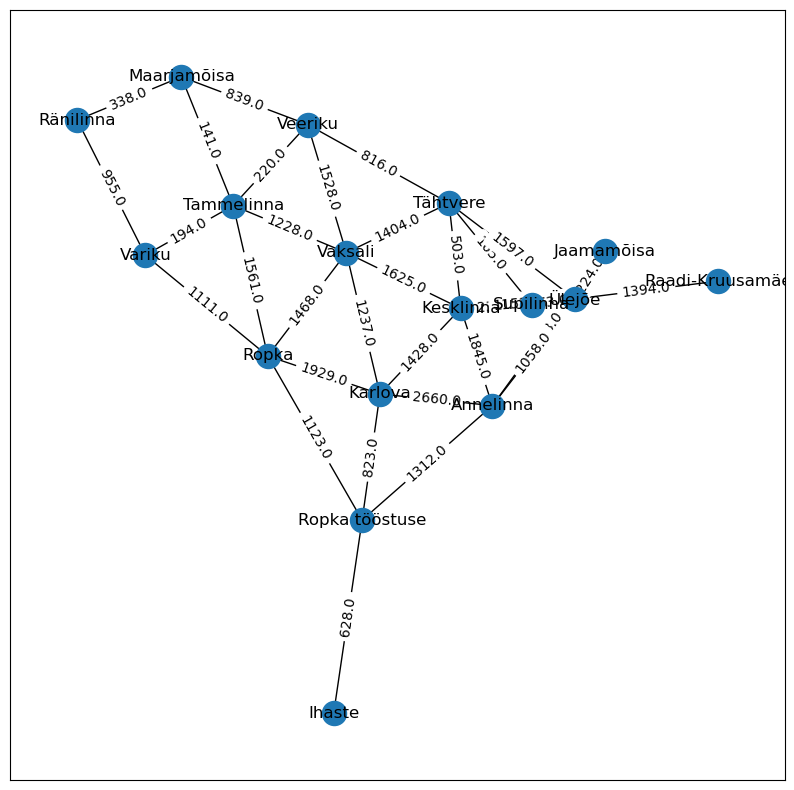

In [22]:
### PLOT THE SIMPLIFIED GRAPH ###

plt.figure(1,figsize=(10,10)) 
pos = nx.spring_layout(graph)
nx.draw_networkx(graph, pos)
labels = nx.get_edge_attributes(graph,'volume')
nx.draw_networkx_edge_labels(graph,pos,edge_labels=labels)
plt.show()

**<span style="color:#394d9e">Plot the graph using actual geolocations and appropriate link width.</span>**

In [23]:
### CREATE A FANCIER VISUALIZATION ###

def visualize_network():
    fig = plt.figure(1, figsize=(10, 10), dpi=90)
    ax = fig.add_subplot(111)
    tartu_districts.plot(ax = ax)
    for index, row in tartu_districts.iterrows():
        text = plt.annotate(text=row.name, xy=((row['centroid'].y, row['centroid'].x)), horizontalalignment='center', fontsize=8)
        text.set_path_effects([patheffects.Stroke(linewidth=3, foreground='white'), patheffects.Normal()])
    for edge in graph.edges:
        district1 = edge[0]
        district2 = edge[1]
        volume = graph.edges[edge]['volume']
        x = [tartu_districts.loc[district1, "centroid"].y, tartu_districts.loc[district2, "centroid"].y]
        y = [tartu_districts.loc[district1, "centroid"].x, tartu_districts.loc[district2, "centroid"].x]
        ax.plot(x, y, color='#444444', linewidth=volume/100)

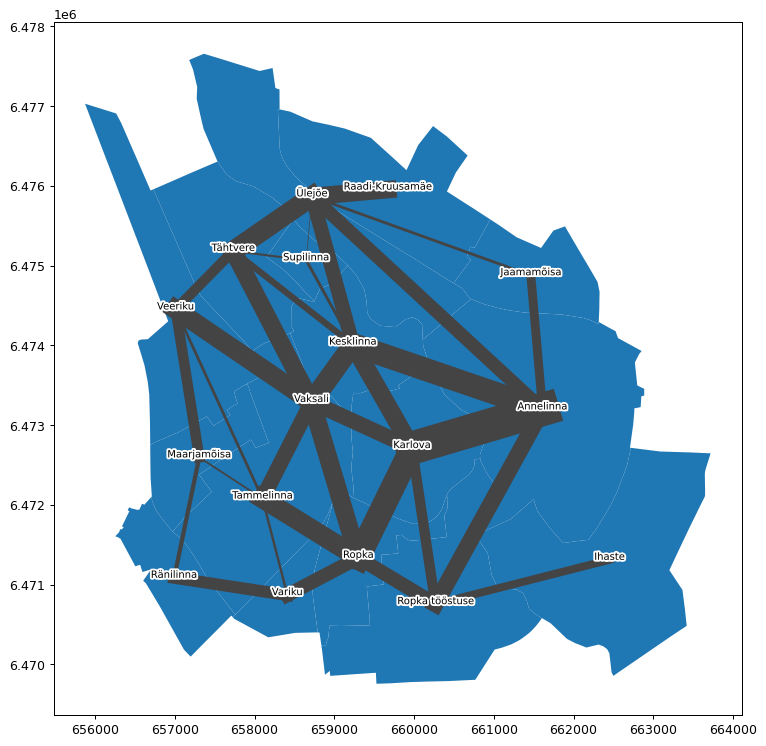

In [24]:
visualize_network()
plt.savefig('example_plot.png')